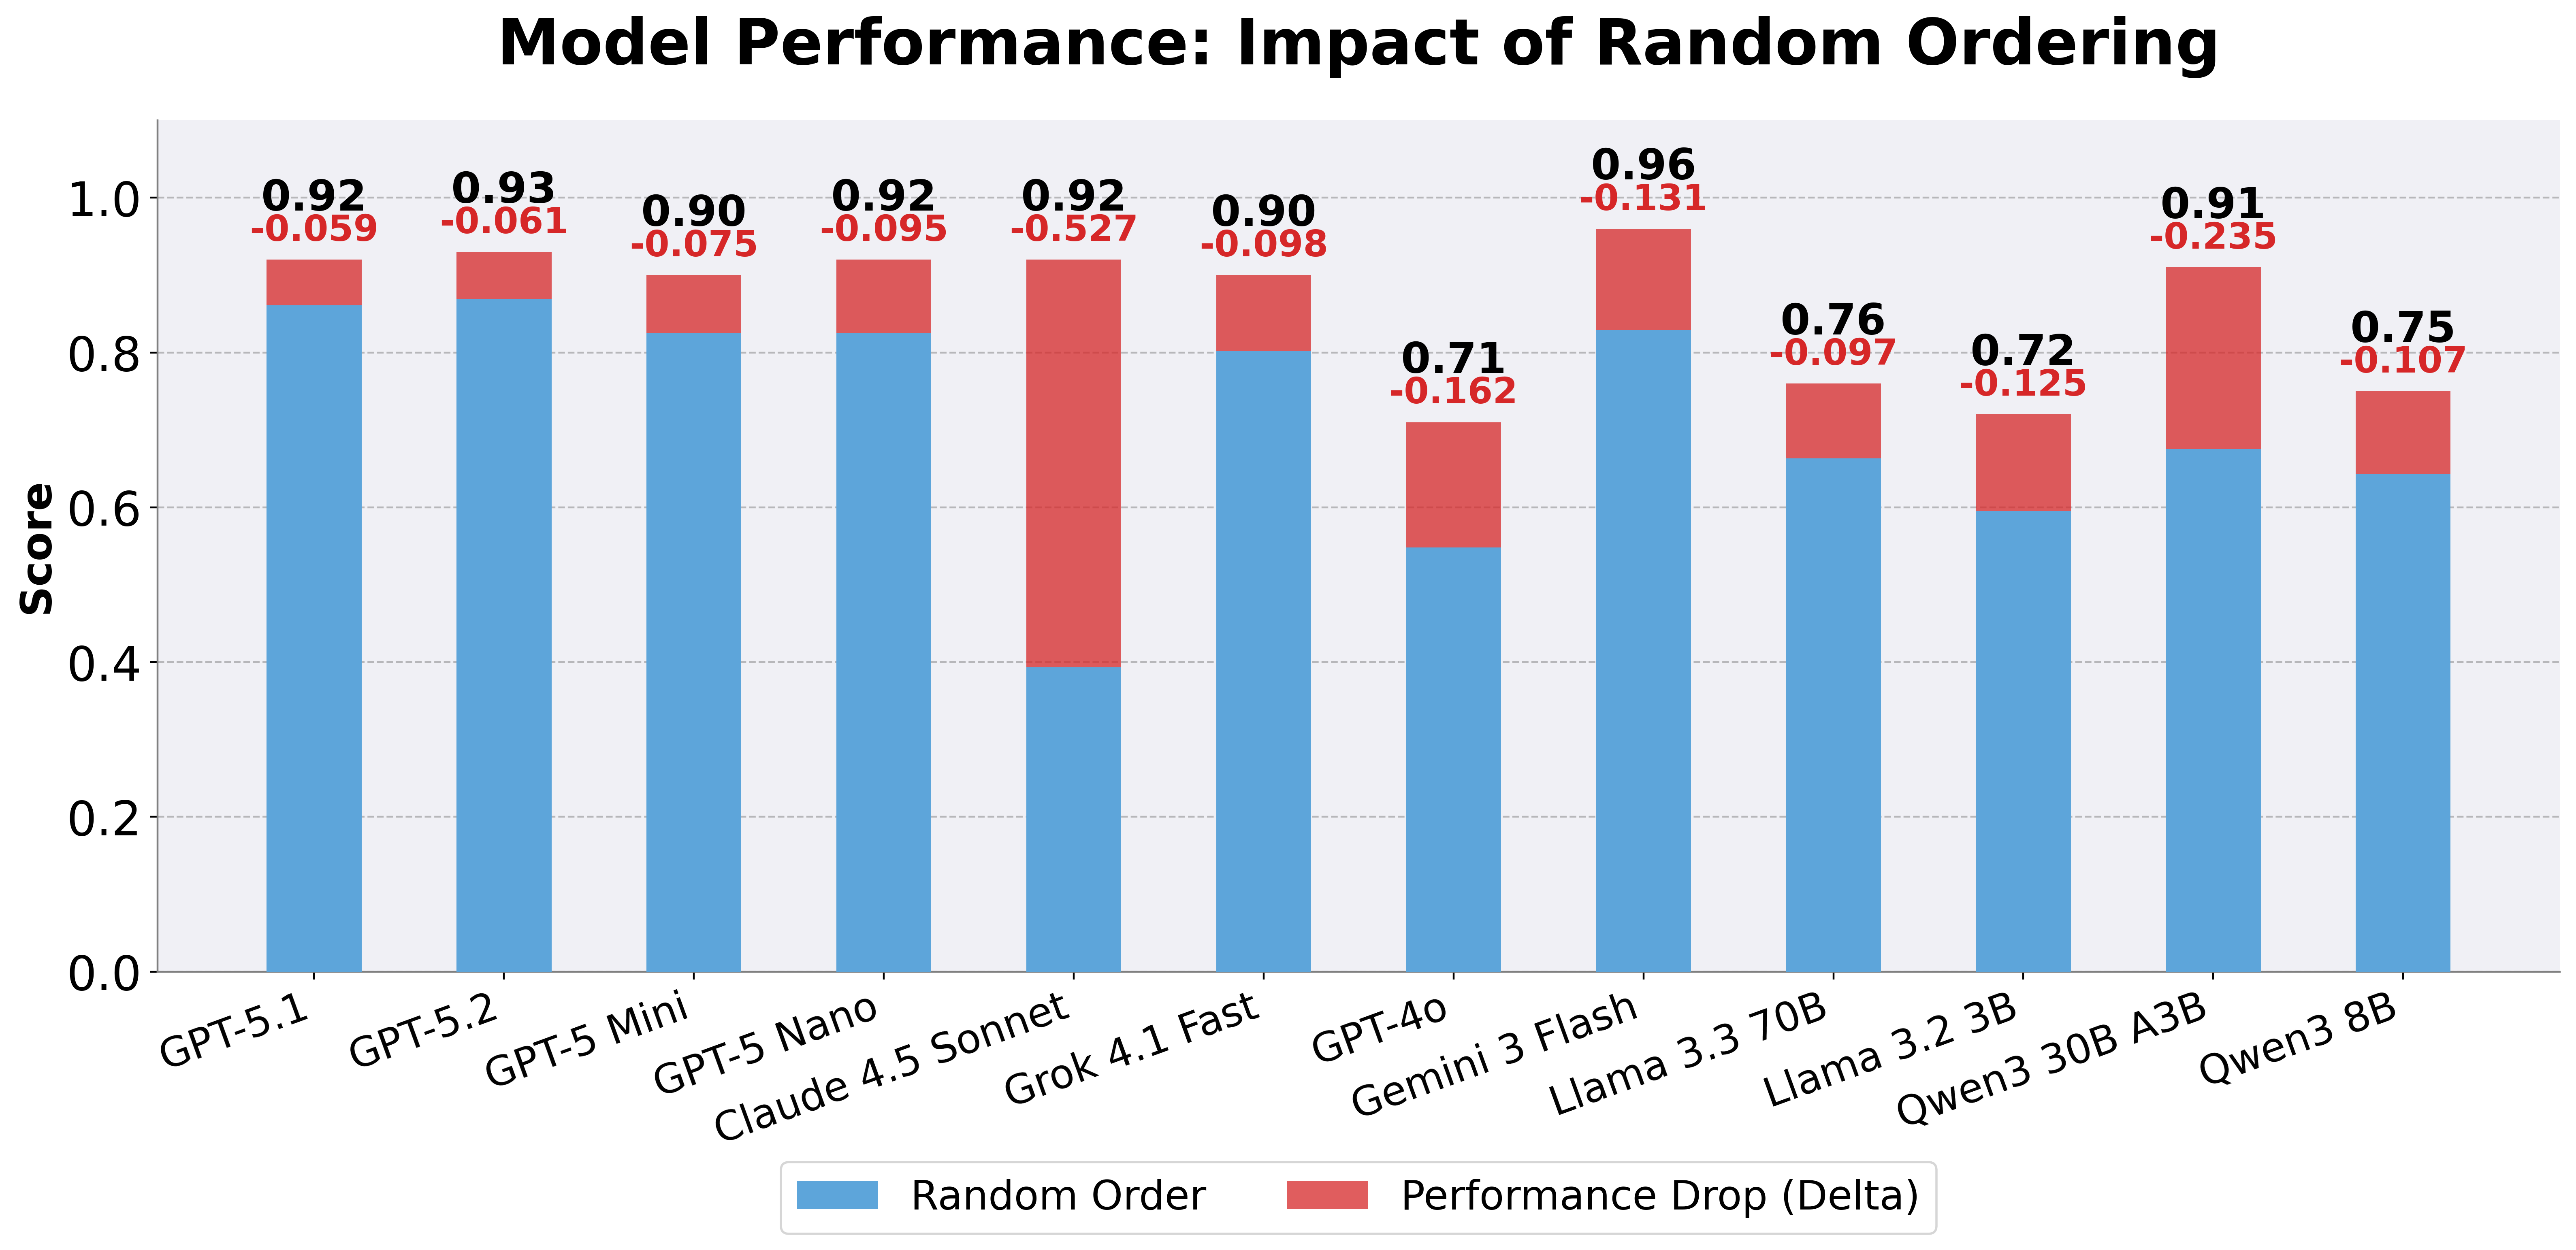

In [4]:
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'  # Use specific font for speed

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# set dpi
plt.rcParams['figure.dpi'] = 400

# set new times roman font
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Times New Roman"]
# plt.rcParams['font.family'] = 'Times New Roman'
# Data from the LaTeX table
data = {
    'Model': [
        'GPT-5.1', 'GPT-5.2', 'GPT-5 Mini', 'GPT-5 Nano', 
        'Claude 4.5 Sonnet', 'Grok 4.1 Fast', 'GPT-4o', 
        'Gemini 3 Flash', 'Llama 3.3 70B', 'Llama 3.2 3B', 
        'Qwen3 30B A3B', 'Qwen3 8B'
    ],
    'Coord': [0.92, 0.93, 0.90, 0.92, 0.92, 0.90, 0.71, 0.96, 0.76, 0.72, 0.91, 0.75],
    'Random': [0.861, 0.869, 0.825, 0.825, 0.393, 0.802, 0.548, 0.829, 0.663, 0.595, 0.675, 0.643],
    'Delta': [-0.059, -0.061, -0.075, -0.095, -0.527, -0.098, -0.162, -0.131, -0.097, -0.125, -0.235, -0.107]
}

df = pd.DataFrame(data)

# Calculate the gap size (absolute difference) for the stacked bar
df['Gap'] = df['Coord'] - df['Random']

# Settings
x = np.arange(len(df['Model']))
width = 0.5  # Slightly wider for single columns

# Create the plot
fig, ax = plt.subplots(figsize=(16, 8))

# Background color
ax.set_facecolor('#F0F0F5')

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.5, color='gray', zorder=0)

# Bars
# 1. Base bar (Random score) - Blue
p1 = ax.bar(x, df['Random'], width, label='Random Order', color='#5da5da', zorder=3)

# 2. Top bar (The Gap/Delta) - Red
# We stack this on top of the Random score to reach the Coord height
p2 = ax.bar(x, df['Gap'], width, bottom=df['Random'], label='Performance Drop (Delta)', color='#D62728', alpha=0.75, zorder=3)

# Add text labels
for i in range(len(df)):
    total_height = df['Coord'][i]
    delta_val = df['Delta'][i]
    
    # 1. Delta Label (Red) - Positioned just above the bar
    ax.annotate(f'{delta_val:.3f}',
                xy=(x[i], total_height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=16, fontweight='bold', color='#D62728')

    # 2. Coord Label (Black) - Positioned above the Delta label
    ax.annotate(f'{total_height:.2f}',
                xy=(x[i], total_height),
                xytext=(0, 18),  # Higher offset to sit above the red text
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=19, fontweight='bold', color='black')

# Axis formatting
ax.set_ylabel('Score', fontsize=19, fontweight='bold')
ax.set_title('Model Performance: Impact of Random Ordering', fontsize=28, fontweight='bold', pad=25)
ax.set_xticks(x)
ax.set_xticklabels(df['Model'], rotation=20, ha='right', fontsize=18)
ax.tick_params(axis='y', labelsize=21)
ax.set_ylim(0, 1.1)  # Set y-axis limit for better spacing

# Legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2, fontsize=18, frameon=True)

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['bottom'].set_color('gray')

plt.tight_layout()
plt.show()
# plt.savefig('stacked_bar_delta.png')

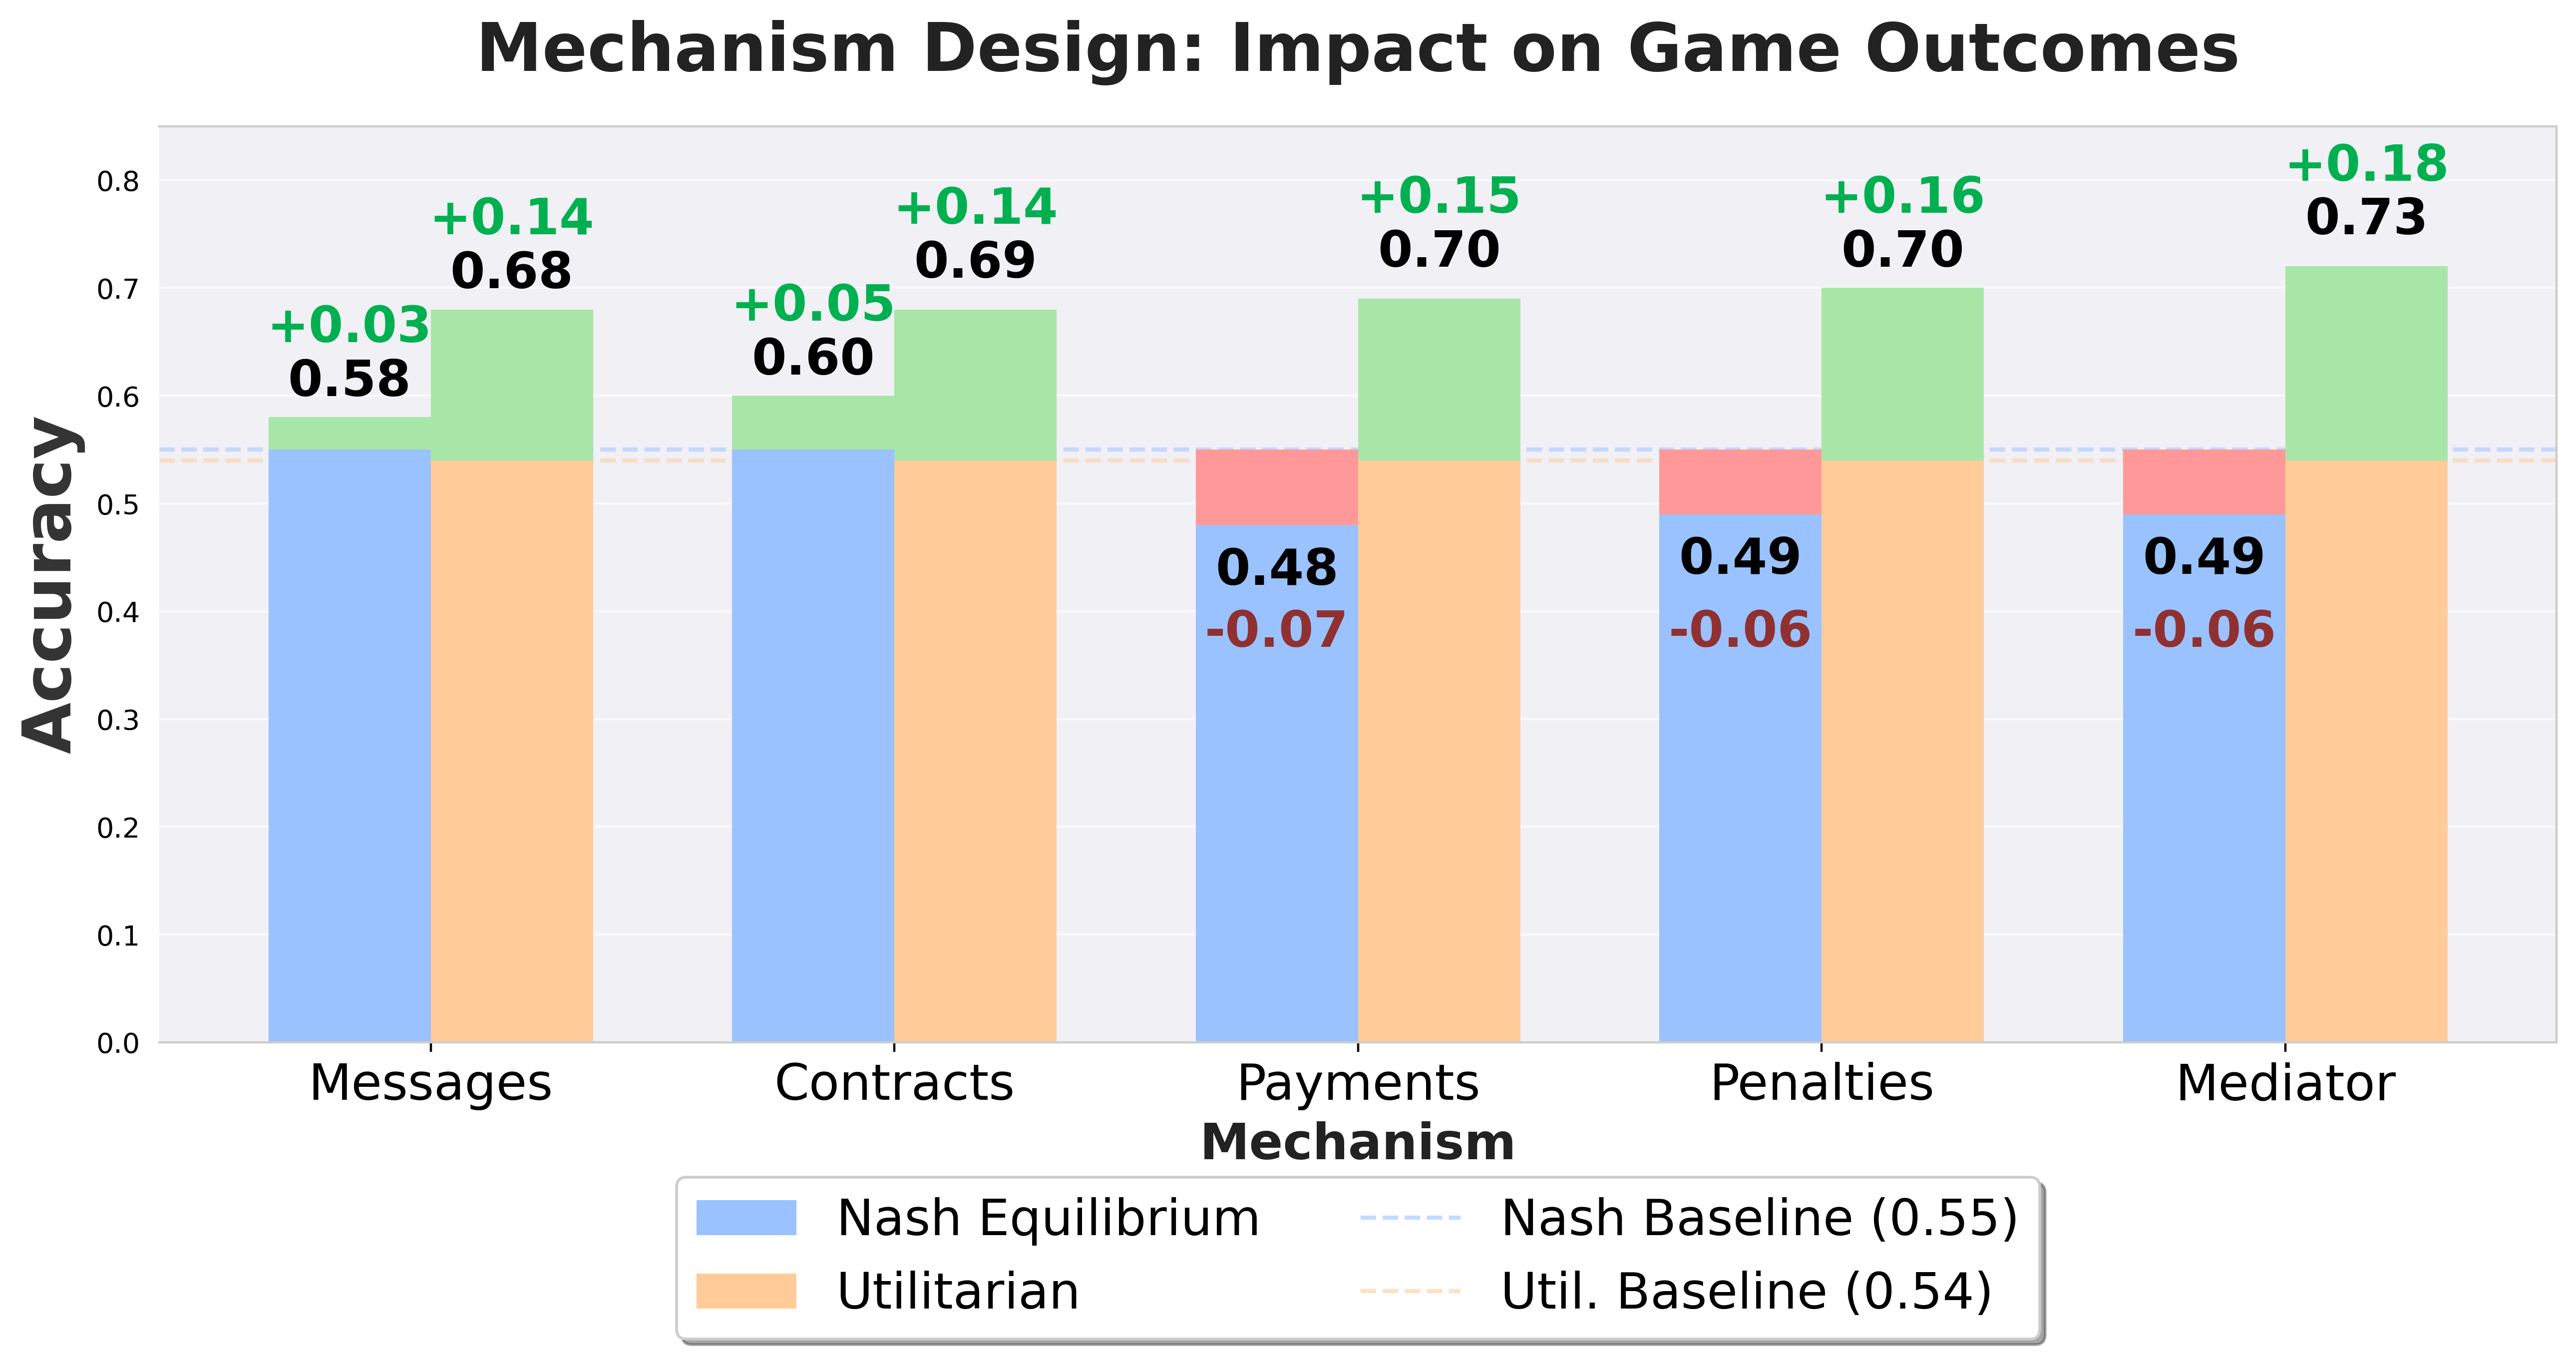

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --- 1. Data Setup ---
categories = ['Messages', 'Contracts', 'Payments', 'Penalties', 'Mediator']

# (Final Value, Displayed Delta)
# Note: I am using the explicit values from the image labels to ensure visual match
nash_data = [
    (0.58, 0.03), # Messages
    (0.60, 0.05), # Contracts
    (0.48, -0.07), # Payments
    (0.49, -0.06), # Penalties
    (0.49, -0.06)  # Mediator (Calculated from baseline 0.55 - 0.06 approx)
]

util_data = [
    (0.68, 0.14), # Messages
    (0.69, 0.14), # Contracts (Math is roughly 0.15, but label says 0.14/0.69)
    (0.70, 0.15), # Payments
    (0.70, 0.16), # Penalties
    (0.73, 0.18)  # Mediator
]

nash_baseline = 0.55
util_baseline = 0.54

# --- 2. Configuration & Colors ---
colors = {
    "nash": "#99c2ff",       # Light Blue
    "util": "#ffcc99",       # Light Orange
    "positive": "#a8e6a8",   # Light Green
    "negative": "#ff9999",   # Light Red
    "text_pos": "#00B050",   # Darker Green for text
    "text_neg": "#C0504D",   # Red for text
    "grid": "#FFFFFF"
}

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 7))

# --- 3. Helper Functions ---

def plot_complex_bar(x_pos, final_val, delta, baseline, base_color):
    """
    Plots the bar based on relation to baseline.
    - If Positive: Base bar goes to Baseline. Green bar stacks on top.
    - If Negative: Base bar goes to Final Val. Red bar stacks on top (filling the gap to baseline).
    """
    if delta >= 0:
        # Positive Case: Base up to baseline, Green add-on
        ax.bar(x_pos, baseline, width, color=base_color, edgecolor='none')
        ax.bar(x_pos, delta, width, bottom=baseline, color=colors["positive"], edgecolor='none')
        
        # Annotations (Floating above)
        ax.text(x_pos, final_val + 0.06, f"+{delta:.2f}", ha='center', va='bottom', 
                fontsize=18, fontweight='bold', color=colors["text_pos"])
        ax.text(x_pos, final_val + 0.01, f"{final_val:.2f}", ha='center', va='bottom', 
                fontsize=18, fontweight='bold', color='black')
        
    else:
        # Negative Case: Base up to final val, Red "gap" up to baseline
        gap = baseline - final_val
        ax.bar(x_pos, final_val, width, color=base_color, edgecolor='none')
        ax.bar(x_pos, gap, width, bottom=final_val, color=colors["negative"], edgecolor='none')
        
        # Annotations (Inside/Around bars)
        # Delta inside the red gap
        ax.text(x_pos, baseline - 0.17, f"{delta:.2f}", ha='center', va='center', 
                fontsize=18, fontweight='bold', color='#903030') # Darker red for contrast inside
        # Final value just inside the blue/orange bar
        ax.text(x_pos, final_val - 0.02, f"{final_val:.2f}", ha='center', va='top', 
                fontsize=18, fontweight='bold', color='black')

# --- 4. Plotting ---

# Draw Baselines first (so bars sit on top if needed, or lines go behind)
# The image shows lines going *behind* the bars usually, but the dashed lines overlay.
# We will draw them with zorder.
ax.axhline(y=nash_baseline, color=colors["nash"], linestyle='--', linewidth=1.5, alpha=0.5, zorder=0)
ax.axhline(y=util_baseline, color=colors["util"], linestyle='--', linewidth=1.5, alpha=0.5, zorder=0)

for i in range(len(categories)):
    # Plot Nash (Left Bar)
    n_final, n_delta = nash_data[i]
    plot_complex_bar(x[i] - width/2, n_final, n_delta, nash_baseline, colors["nash"])
    
    # Plot Util (Right Bar)
    u_final, u_delta = util_data[i]
    plot_complex_bar(x[i] + width/2, u_final, u_delta, util_baseline, colors["util"])

# --- 5. Styling ---

ax.set_ylabel('Accuracy', fontsize=24, fontweight='bold', color='#333333')
ax.set_title('Mechanism Design: Impact on Game Outcomes', 
             fontsize=24, fontweight='bold', pad=20, color='#222222')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=18)
ax.set_ylim(0, 0.85)

# Add faint y-grid
ax.yaxis.grid(True, linestyle='-', which='major', color=colors["grid"], alpha=0.7)
ax.set_axisbelow(True)

# Spines
for spine in ax.spines.values():
    spine.set_color('#CCCCCC')

# Remove top and right box lines mostly
ax.spines['top'].set_visible(True) 
ax.spines['right'].set_visible(True)

# Add "Mechanism" X-label
ax.set_xlabel('Mechanism', fontsize=18, fontweight='bold', color='#222222')

# --- 6. Legend ---

# Create custom legend elements to match the image style
legend_elements = [
    Patch(facecolor=colors["nash"], label='Nash Equilibrium'),
    Patch(facecolor=colors["util"], label='Utilitarian'),
    Line2D([0], [0], color=colors["nash"], lw=1.5, linestyle='--', alpha=0.6, label=f'Nash Baseline ({nash_baseline})'),
    Line2D([0], [0], color=colors["util"], lw=1.5, linestyle='--', alpha=0.6, label=f'Util. Baseline ({util_baseline})')
]

# Place legend at the bottom
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=2, fontsize=18)

ax.set_ylim(0.0, 0.85)
# set backgroun color to: #eaeaf2
# remove vertical accuracy bar
ax.spines['left'].set_visible(False)
ax.yaxis.set_ticks_position('none')
# remove labels
# ax.set_yticklabels([0.4, 0.5, 0.6, 0.7, 0.8])

# set figure bar background color
# fig.patch.set_facecolor('#eaeaf2')
ax.set_facecolor("#ffffff")
ax.set_facecolor('#F0F0F5')

plt.tight_layout()
plt.show()

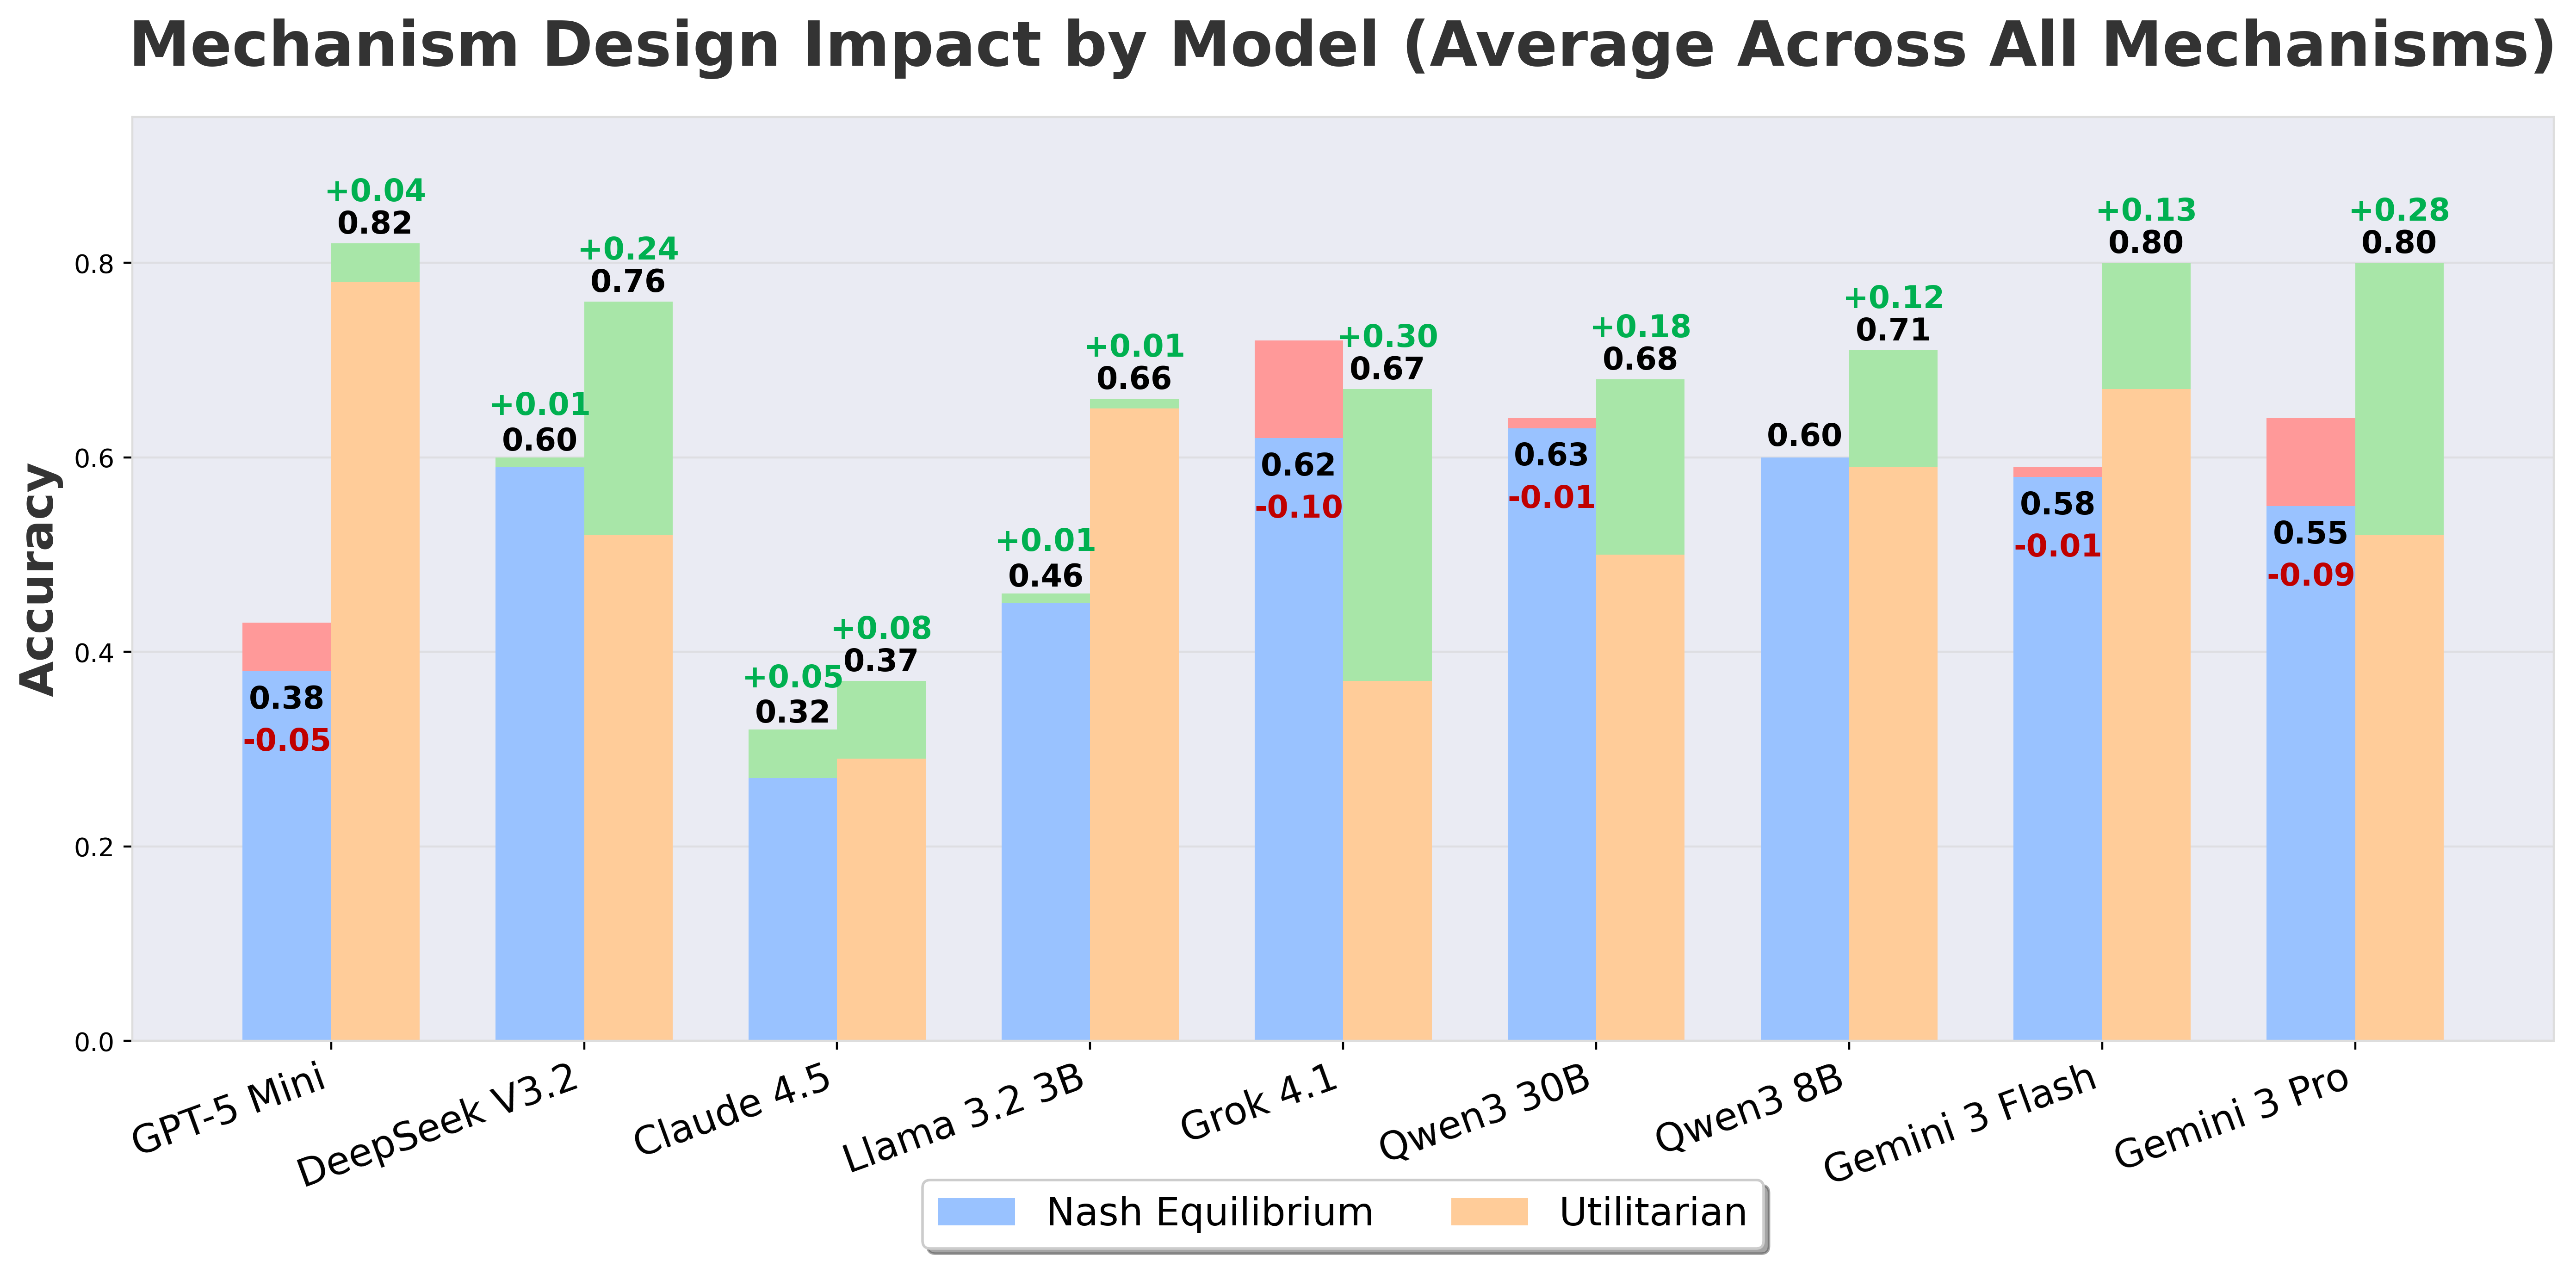

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Setup ---
# Structure: (Final Value, Delta)
# Delta: Positive means Green (added on top), Negative means Red (stacked on top of final to show loss)
data = {
    "GPT-5 Mini":      {"nash": (0.38, -0.05), "util": (0.82, 0.04)},
    "DeepSeek V3.2":   {"nash": (0.60, 0.01),  "util": (0.76, 0.24)},
    "Claude 4.5":      {"nash": (0.32, 0.05),  "util": (0.37, 0.08)},
    "Llama 3.2 3B":    {"nash": (0.46, 0.01),  "util": (0.66, 0.01)},
    "Grok 4.1":        {"nash": (0.62, -0.10), "util": (0.67, 0.30)},
    "Qwen3 30B":       {"nash": (0.63, -0.01), "util": (0.68, 0.18)},
    "Qwen3 8B":        {"nash": (0.60, 0.00),  "util": (0.71, 0.12)},
    "Gemini 3 Flash":  {"nash": (0.58, -0.01), "util": (0.80, 0.13)},
    "Gemini 3 Pro":    {"nash": (0.55, -0.09), "util": (0.80, 0.28)},
}

models = list(data.keys())
nash_vals = [data[m]["nash"] for m in models]
util_vals = [data[m]["util"] for m in models]

# --- 2. Configuration & Colors ---
colors = {
    "nash_base": "#99c2ff",  # Light Blue
    "util_base": "#ffcc99",  # Light Orange
    "positive":  "#a8e6a8",  # Light Green
    "negative":  "#ff9999",  # Light Red
    "text_pos":  "#00B050",  # Darker Green for text
    "text_neg":  "#C00000",  # Dark Red for text
    "text_main": "#000000"   # Black
}

x = np.arange(len(models))
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(14, 7))

# --- 3. Plotting Helper Function ---
def plot_stacked_bar(x_pos, values, base_color):
    final_val, delta = values
    
    # Logic:
    # If Delta > 0: Base is (Final - Delta), Top is Delta (Green)
    # If Delta < 0: Base is Final, Top is abs(Delta) (Red)
    # If Delta == 0: Base is Final, Top is 0
    
    if delta > 0:
        base_h = final_val - delta
        top_h = delta
        top_color = colors["positive"]
    elif delta < 0:
        base_h = final_val
        top_h = abs(delta)
        top_color = colors["negative"]
    else:
        base_h = final_val
        top_h = 0
        top_color = colors["positive"] # Placeholder

    # Plot Base
    ax.bar(x_pos, base_h, width, color=base_color, edgecolor='none')
    
    # Plot Top (Impact)
    if top_h > 0:
        ax.bar(x_pos, top_h, width, bottom=base_h, color=top_color, edgecolor='none')
        
    return base_h + top_h # Return total height for annotation placement

# --- 4. Loop to Create Bars ---
for i in range(len(models)):
    # Nash Bars (Left)
    h1 = plot_stacked_bar(x[i] - width/2, nash_vals[i], colors["nash_base"])
    
    # Util Bars (Right)
    h2 = plot_stacked_bar(x[i] + width/2, util_vals[i], colors["util_base"])

    # Annotations for Nash
    n_final, n_delta = nash_vals[i]
    if n_delta != 0:
        # Delta Label
        if n_delta > 0:
            label_color = colors["text_pos"] if n_delta > 0 else colors["text_neg"]
            delta_str = f"{n_delta:+.2f}"
            ax.text(x[i] - width/2, h1 + 0.037, delta_str, ha='center', va='bottom', 
                    fontsize=12, fontweight='bold', color=label_color)
            # Final Value Label
            ax.text(x[i] - width/2, h1 + 0.032, f"{n_final:.2f}", ha='center', va='top', 
                    fontsize=12, fontweight='bold', color=colors["text_main"])
        else:
            label_color = colors["text_pos"] if n_delta > 0 else colors["text_neg"]
            delta_str = f"{n_delta:+.2f}"
            ax.text(x[i] - width/2, h1 + n_delta - 0.057, delta_str, ha='center', va='top', 
                    fontsize=12, fontweight='bold', color=label_color)
            # Final Value Label
            ax.text(x[i] - width/2, h1 + n_delta - 0.045, f"{n_final:.2f}", ha='center', va='bottom', 
                    fontsize=12, fontweight='bold', color=colors["text_main"])
    else:
        # Just Final Value if no delta
        ax.text(x[i] - width/2, h1 + 0.005, f"{n_final:.2f}", ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color=colors["text_main"])

    # Annotations for Util
    u_final, u_delta = util_vals[i]
    label_color = colors["text_pos"] if u_delta > 0 else colors["text_neg"]
    delta_str = f"{u_delta:+.2f}"
    ax.text(x[i] + width/2, h2 + 0.037, delta_str, ha='center', va='bottom', 
            fontsize=12, fontweight='bold', color=label_color)
    # Final Value Label
    ax.text(x[i] + width/2, h2 + 0.035, f"{u_final:.2f}", ha='center', va='top', 
            fontsize=12, fontweight='bold', color=colors["text_main"])
    # else:
    #     ax.text(x[i] + width/2, h2 + 0.005, f"{u_final:.2f}", ha='center', va='bottom', 
    #             fontsize=12, fontweight='bold', color=colors["text_main"])

# --- 5. Formatting ---
ax.set_ylabel('Accuracy', fontsize=18, fontweight='bold', color='#333333')
ax.set_title('Mechanism Design Impact by Model (Average Across All Mechanisms)', 
             fontsize=24, fontweight='bold', pad=20, color='#333333')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right', fontsize=15)
ax.set_ylim(0, 0.95)

# Grid setup
ax.yaxis.grid(True, linestyle='-', which='major', color='lightgrey', alpha=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['top'].set_color('#DDDDDD')
ax.spines['right'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')
ax.spines['left'].set_color('#DDDDDD')

# Legend setup (Creating custom handles to match the simplified legend in the image)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors["nash_base"], label='Nash Equilibrium'),
    Patch(facecolor=colors["util_base"], label='Utilitarian')
]

# Place legend at bottom center
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.13),
          fancybox=True, shadow=True, ncol=2, fontsize=15)
ax.set_facecolor('#eaebf3')

plt.tight_layout()
plt.show()

Columns in gamify data: ['log_id', 'model_name', 'n_samples', 'nash_accuracy', 'utilitarian_accuracy', 'rawlsian_accuracy', 'nash_social_welfare_accuracy', 'utilitarian_efficiency', 'rawlsian_efficiency', 'nash_social_welfare_efficiency', 'model_clean']

Saved comparison plot to: output.png
Mean Statistics:
Nash Mean Delta: +0.0620
Util Mean Delta: -0.0406


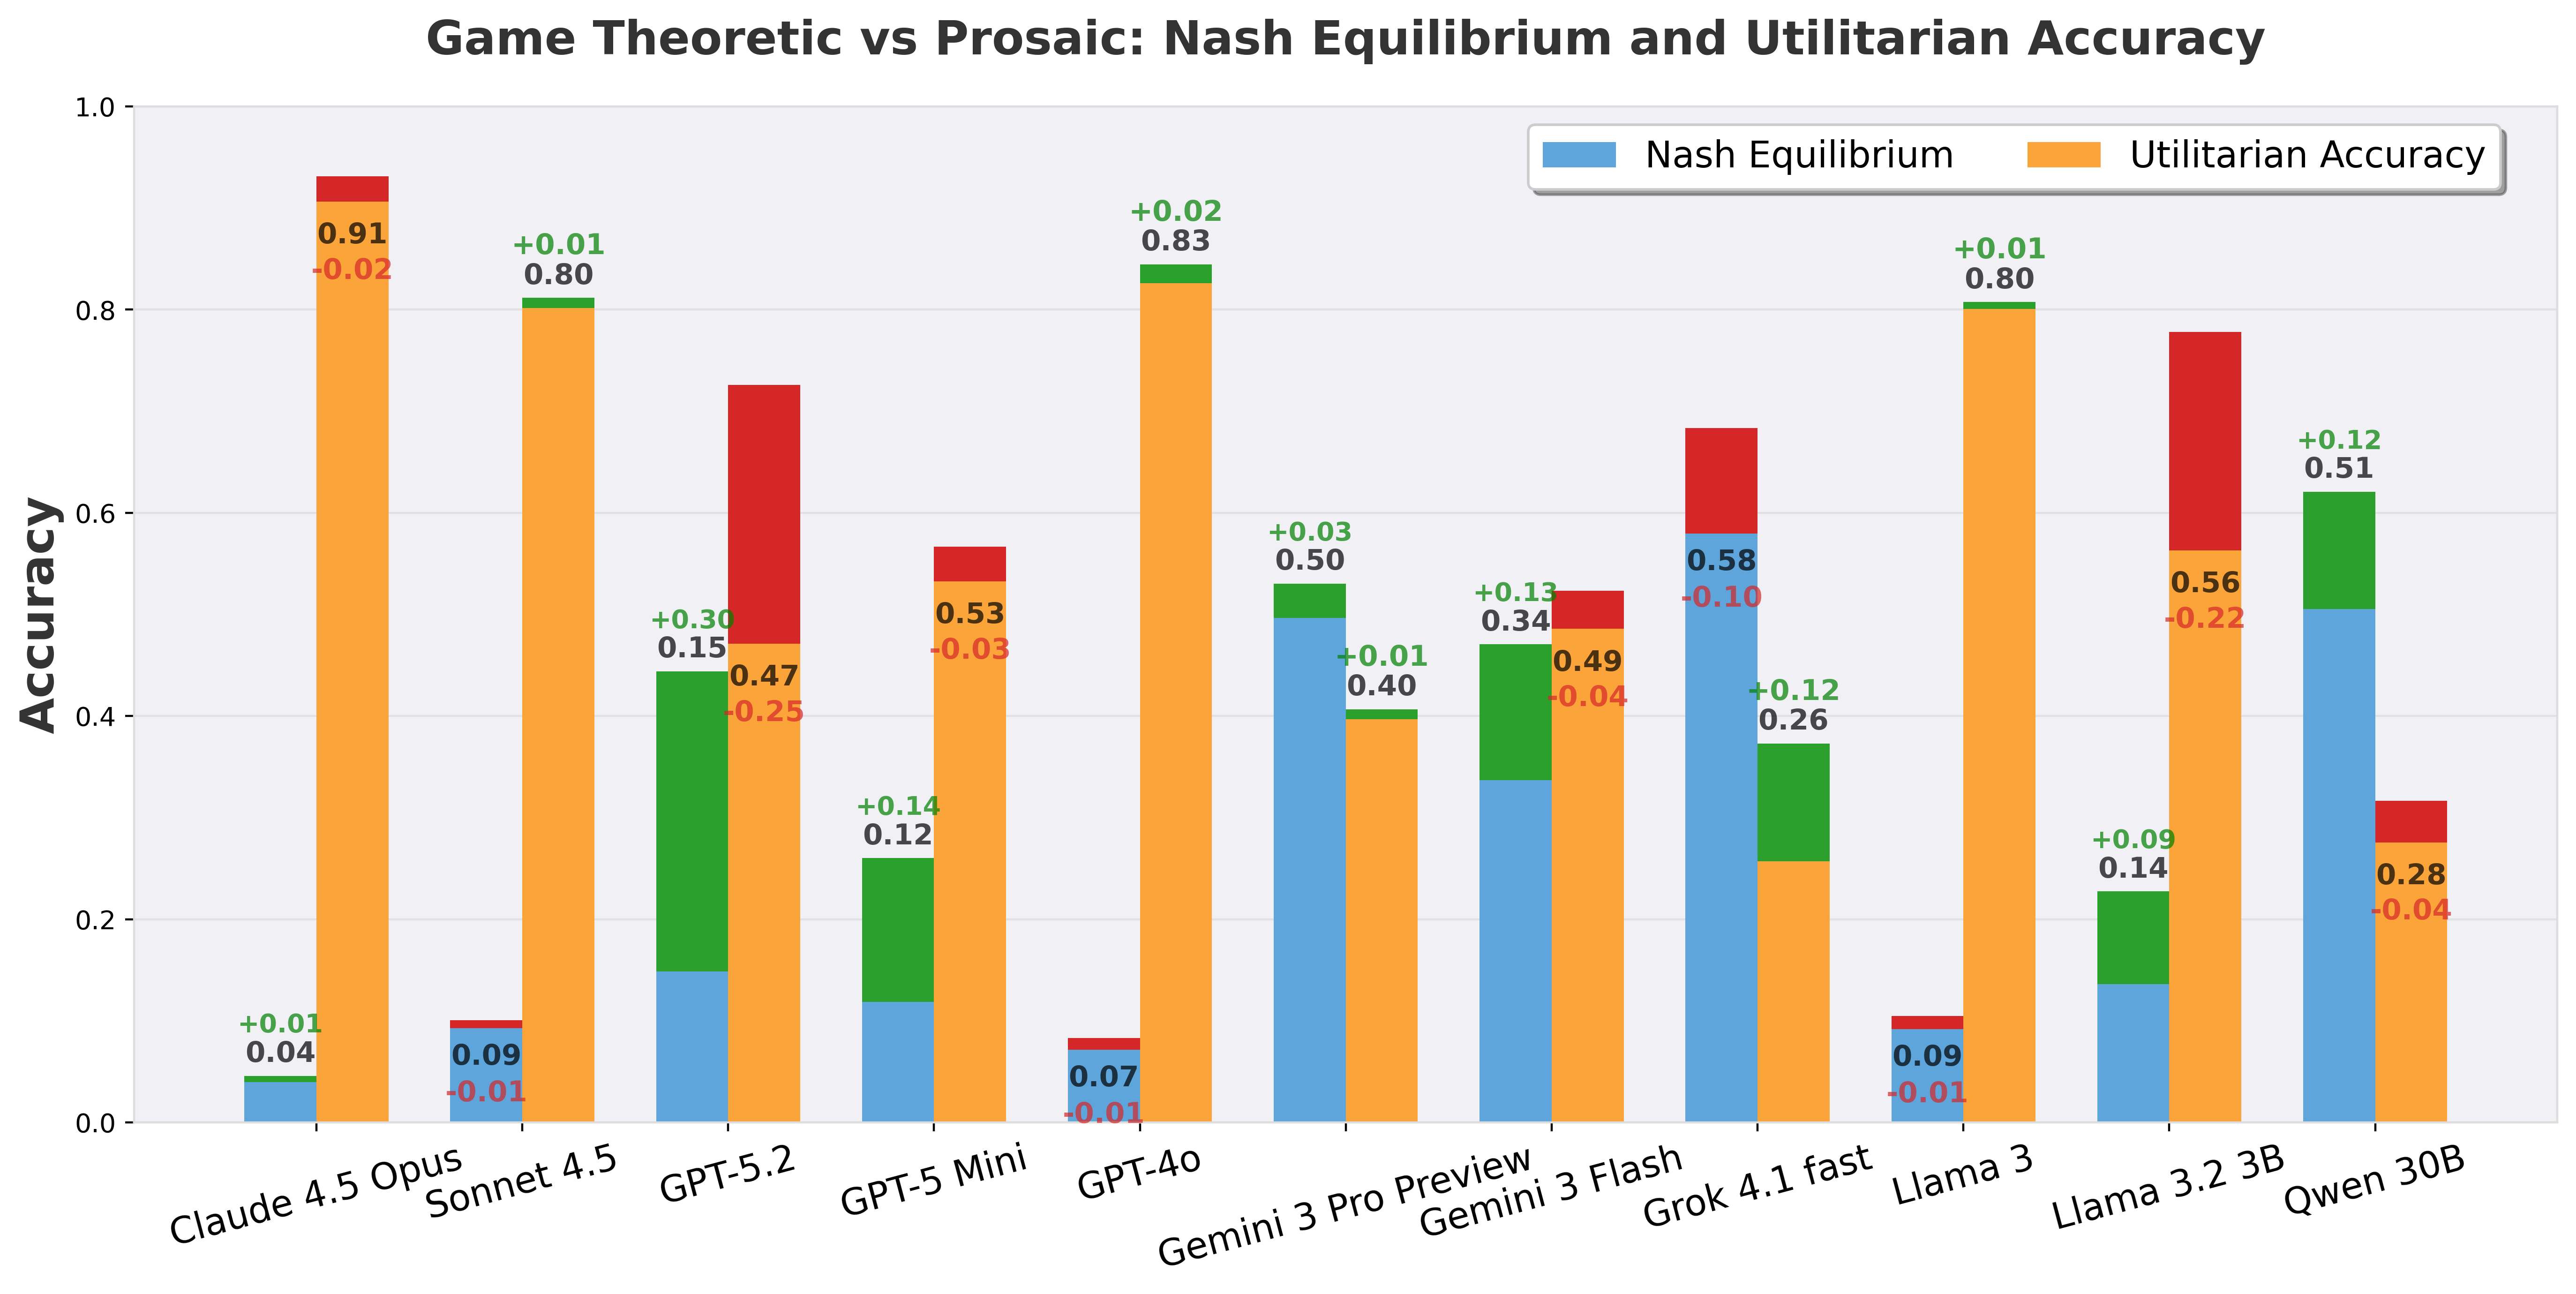

In [88]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.patches import Patch

from eval.analysis.utils import shorten_model_name

def load_and_prepare_data(csv_path: Path) -> pd.DataFrame:
    """Load CSV and prepare for plotting."""
    df = pd.read_csv(csv_path)
    
    # Ensure required columns exist
    required_cols = ["model_name", "nash_accuracy", "nash_social_welfare_accuracy"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {csv_path}: {missing}")
    
    # Clean and map model names using utils
    df["model_clean"] = df["model_name"].apply(shorten_model_name)
    
    return df

def plot_comparison(gamify_path: Path, standard_path: Path, output_path: Path) -> None:
    """Create overlapping bar plot comparing gamify vs standard metrics with specific styling."""
    
    # --- 1. Load and Prepare Data ---
    gamify_df = load_and_prepare_data(gamify_path)
    standard_df = load_and_prepare_data(standard_path)
    
    print(f"Columns in gamify data: {gamify_df.columns.tolist()}")
    
    # Define specific model order
    target_models = [
        'Claude 4.5 Opus', 'Sonnet 4.5', 'GPT-5.2', 'GPT-5 Mini', 
        'GPT-4o', 'Gemini 3 Pro Preview', 'Gemini 3 Flash', 
        'Grok 4.1 fast', 'Llama 3', 'Llama 3.2 3B', 'Qwen 30B'
    ]
    
    # Prepare data lists
    models_clean = []
    nash_data = [] # Stores tuple (final_val, delta)
    util_data = [] # Stores tuple (final_val, delta)
    
    for model in target_models:
        # Check if model exists in both (using partial string matching or exact)
        # Assuming exact match based on previous script logic, but handling the 'Gemi' rename
        
        # Standardize names in DF if necessary (optional, based on your previous replace logic)
        # Here we assume the DFs contain the original names, so we might need to map them
        search_model = model.replace("Gemini 3 Flash", "Gemi 3 Flash") if "Gemini 3 Flash" in model else model
        g_row = gamify_df[gamify_df["model_clean"] == search_model]
        s_row = standard_df[standard_df["model_clean"] == search_model]
        
        if not g_row.empty and not s_row.empty:
            models_clean.append(model)
            
            # Nash Values
            g_nash = g_row.iloc[0]["nash_accuracy"]
            s_nash = s_row.iloc[0]["nash_accuracy"]
            nash_diff = g_nash - s_nash
            nash_data.append((g_nash, nash_diff))
            
            # Util Values
            g_util = g_row.iloc[0]["utilitarian_accuracy"]
            s_util = s_row.iloc[0]["utilitarian_accuracy"]
            util_diff = g_util - s_util
            util_data.append((g_util, util_diff))

    # --- 2. Configuration & Colors ---
    # colors = {
    #     "nash_base": "#99c2ff",  # Light Blue
    #     "util_base": "#ffcc99",  # Light Orange
    #     "positive":  "#a8e6a8",  # Light Green
    #     "negative":  "#ff9999",  # Light Red
    #     "text_pos":  "#00B050",  # Darker Green for text
    #     "text_neg":  "#C00000",  # Dark Red for text
    #     "text_main": "#000000"   # Black
    # }

    colors = {
        "nash_base": "#5da5da",  # The exact strong Blue from your script
        "util_base": "#faa43a",  # A strong Orange to match the saturation of the Blue
        "positive":  "#2ca02c",  # A strong Green (Matplotlib default) for positive deltas
        "negative":  "#D62728",  # The exact strong Red from your script
        "text_pos":  "#008000",  # Dark Green for positive text labels
        "text_neg":  "#D62728",  # The exact strong Red for negative text labels
        "text_main": "#000000"   # Black
    }
    
    x = np.arange(len(models_clean))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # --- 3. Plotting Helper Function ---
    def plot_stacked_bar(x_pos, final_val, delta, base_color):
        # Logic:
        # If Delta > 0 (Improvement): Base is Standard (Final - Delta), Top is Delta (Green)
        # If Delta < 0 (Decline): Base is Final (Gamify), Top is Abs(Delta) (Red) -> Total height visualizes the Standard
        
        if delta > 0:
            base_h = final_val - delta # = Standard
            top_h = delta
            top_color = colors["positive"]
        elif delta < 0:
            base_h = final_val # = Gamify
            top_h = abs(delta)
            top_color = colors["negative"]
        else:
            base_h = final_val
            top_h = 0
            top_color = colors["positive"]

        # Plot Base
        ax.bar(x_pos, base_h, width, color=base_color, edgecolor='none')
        
        # Plot Top (Impact)
        if top_h > 0:
            ax.bar(x_pos, top_h, width, bottom=base_h, color=top_color, edgecolor='none')
            
        return base_h + top_h # Return visual total height for annotation

    # --- 4. Render Bars and Annotations ---
    for i in range(len(models_clean)):
        # --- Nash Bars (Left) ---
        n_final, n_delta = nash_data[i]
        h1 = plot_stacked_bar(x[i] - width/2, n_final, n_delta, colors["nash_base"])
        
        # Annotations for Nash
        # Determine label position based on delta direction to avoid overlap
        label_color = colors["text_pos"] if n_delta >= 0 else colors["text_neg"]
        delta_str = f"{n_delta:+.2f}"
        
        if abs(n_delta) > 0.001:
            # Show Delta
            # Show Value (if delta is negative, show value lower; if positive, show value on bar)
            # Adjusting "va" (vertical alignment) slightly based on space
            if n_delta > 0:
                ax.text(x[i] - width/2, h1 + 0.037, delta_str, ha='center', va='bottom', 
                        fontsize=10, fontweight='bold', color=label_color, alpha=0.7)
                ax.text(x[i] - width/2, h1 + 0.035, f"{n_final-n_delta:.2f}", ha='center', va='top', 
                        fontsize=11, fontweight='bold', color=colors["text_main"], alpha=0.7)
            else:
                ax.text(x[i] - width/2, h1 - abs(n_delta) - 0.015, f"{n_final:.2f}", ha='center', va='top', 
                        fontsize=11, fontweight='bold', color=colors["text_main"], alpha=0.7)
                ax.text(x[i] - width/2, h1 + n_delta - 0.078, delta_str, ha='center', va='bottom', 
                        fontsize=11, fontweight='bold', color=label_color, alpha=0.7)
        else:
            # No difference
            ax.text(x[i] - width/2, h1 + 0.01, f"{n_final:.2f}", ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', color=colors["text_main"])

        # --- Util Bars (Right) ---
        u_final, u_delta = util_data[i]
        h2 = plot_stacked_bar(x[i] + width/2, u_final, u_delta, colors["util_base"])

        # Annotations for Util
        label_color = colors["text_pos"] if u_delta >= 0 else colors["text_neg"]
        delta_str = f"{u_delta:+.2f}"

        if abs(u_delta) > 0.001:
            # Show value
            if u_delta > 0:
                ax.text(x[i] + width/2, h2 + 0.037, delta_str, ha='center',va='bottom', 
                        fontsize=11, fontweight='bold', color=label_color, alpha=0.7)
                ax.text(x[i] + width/2, h2 + 0.035, f"{u_final-u_delta:.2f}", ha='center', va='top', 
                        fontsize=11, fontweight='bold', color=colors["text_main"], alpha=0.7)
            else:
                ax.text(x[i] + width/2, h2 - abs(u_delta) - 0.02, f"{u_final:.2f}", ha='center', va='top', 
                         fontsize=11, fontweight='bold', color=colors["text_main"], alpha=0.7)
                 
                ax.text(x[i] + width/2, h2 + u_delta - 0.082, delta_str, ha='center', va='bottom', 
                        fontsize=11, fontweight='bold', color=label_color, alpha=0.7)
        else:
            ax.text(x[i] + width/2, h2 + 0.01, f"{u_final:.2f}", ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', color=colors["text_main"])

    # --- 5. Styling & Formatting ---
    ax.set_ylabel('Accuracy', fontsize=18, fontweight='bold', color='#333333')
    ax.set_title('Game Theoretic vs Prosaic: Nash Equilibrium and Utilitarian Accuracy', 
                 fontsize=18, fontweight='bold', pad=20, color='#333333')
    
    ax.set_xticks(x)
    ax.set_xticklabels(models_clean, rotation=15, ha='center', fontsize=14)
    
    # Dynamic Y-Limit based on data
    all_vals = [x[0] for x in nash_data] + [x[0] for x in util_data]
    max_val = max(all_vals) if all_vals else 1.0
    ax.set_ylim(0, 1) # Give headroom for labels

    # Grid setup
    ax.yaxis.grid(True, linestyle='-', which='major', color='lightgrey', alpha=0.5)
    ax.set_axisbelow(True)

    # Spine styling
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('#DDDDDD')

    # Legend
    legend_elements = [
        Patch(facecolor=colors["nash_base"], label='Nash Equilibrium'),
        Patch(facecolor=colors["util_base"], label='Utilitarian Accuracy')
    ]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.776, 1),
              fancybox=True, shadow=True, ncol=2, fontsize=14)
    
    # Background color
    # ax.set_facecolor('#eaebf3')
    ax.set_facecolor('#F0F0F5')
    fig.patch.set_facecolor('white') # Outer background

    plt.tight_layout()
    
    # --- 6. Stats & Saving ---
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    # Calculate stats for console output
    nash_diffs = [d for _, d in nash_data]
    util_diffs = [d for _, d in util_data]
    
    print(f"\nSaved comparison plot to: {output_path}")
    print("="*60)
    print("Mean Statistics:")
    print(f"Nash Mean Delta: {np.mean(nash_diffs):+.4f}")
    print(f"Util Mean Delta: {np.mean(util_diffs):+.4f}")
    print("="*60)

    # plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

# Example Usage
plot_comparison(Path("results/gamify.csv"), Path("results/standard.csv"), Path("output.png"))